To implement the evolution of the states when an external field is coupled to it
- length gauge is used: H = T + V_softcore + E(t)x
- E(t) has a temporal only profile, meaning as the CN operator goes through time steps, the value of E(t) for that step will change
- Also, since we are in the dipole approximation E(t) has NO spatial depedence.
- So, for each of those time steps, the value of E(t) over the entire x_vec spatial range is constant
- Thus, we simply add a constant to the H_diag of the H in CN step
- We are also not in the imaginary time anymore, as eigenstates are already found and we want to note the evolution of said eigenstates through real time.
- Initial state (before external field coupling and CN evolution) is Psi0
- Since coupling frequency (or Energy, as we are in a.u.) is equal to the difference between the first two states, jump from the GS to first eigenstate will be noticed.


In [30]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import sparse
# from matplotlib.backends.backend_pdf import PdfPages


# creates the matrices necessary for CN
def create_Apl_Ami_Heff_M2_matrices(x_vec, V_vec, Z, ell, deltaTau):
    Delta_r = x_vec[1] - x_vec[0]
    N = len(x_vec)
    
    D_lower = np.ones(N-1, dtype=complex)/(Delta_r**2)
    D_upper = np.ones(N-1, dtype=complex)/(Delta_r**2)
    D_diag = -2*np.ones(N, dtype=complex)/(Delta_r**2)
    
    D = get_sparseMatrix(D_lower, D_diag, D_upper)
    
    M_2_lower = -np.ones(N-1, dtype=complex)/6
    M_2_diag = -10*np.ones(N, dtype=complex)/6
    M_2_upper = -np.ones(N-1, dtype=complex)/6
   
    M_2 = get_sparseMatrix(M_2_lower, M_2_diag, M_2_upper)
    
    V_matrix = sparse.spdiags([V_vec], [0], N, N)
    
    # Hamiltonian (effective)
    H_2 = D + M_2@V_matrix
    
    # CN A matrices
    A_pl = M_2 + 0.5j * deltaTau * H_2
    A_mi = M_2 - 0.5j * deltaTau * H_2
    return A_pl, A_mi, H_2, M_2

def get_sparseMatrix(upper, mid, lower):
    return sparse.diags([lower, mid, upper], offsets=[-1, 0, 1], format="csr")

# Crank-Nicolson propagation
def CN_propagation(A_pl, A_mi, psi, r, N_iter=1000):
    A_pl_lower = get_lower(A_pl)
    A_pl_diag = get_diag(A_pl)
    A_pl_upper = get_upper(A_pl)
    
    for i in (range(N_iter)): # Iterate for imaginary time
        psi_new = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi)
        psi = normalize(psi_new, r)
    return psi

# Compute energy (expectation value of Hamiltonian)
def calc_E_withNumerov(psi, H_2, M_2, r):
    return project(psi, H_2 @ psi, r)/project(psi, M_2 @ psi, r)


def get_diag(mat):
    return np.array([mat[i, i] for i in range(mat.shape[0])], dtype=complex)
def get_upper(mat):
    return np.array([mat[i-1, i] for i in range(1, mat.shape[0])], dtype=complex)
def get_lower(mat):
    return np.array([mat[i, i-1] for i in range(1, mat.shape[0])], dtype=complex)

# general scalar projection function
def project(psi1, psi2, x_vec):
    return np.trapz(np.conj(psi1)*psi2, x=x_vec)
def normalize(psi, x_vec):
    return psi/np.sqrt(project(psi, psi, x_vec))

def thomas_algorithm(a, b, c, d):
    n = len(b)
    
    # Create copies of the input arrays to modify during elimination
    bp = np.copy(b).astype(complex) # diagonal copy
    dp = np.copy(d).astype(complex) # Right-hand side copy
    
    # Forward elimination
    for i in range(1, n):
        # Modify the coefficients in the sub-diagonal and right-hand side
        w = a[i-1] / bp[i-1]
        bp[i] = b[i] - w * c[i-1]
        dp[i] = d[i] - w * dp[i-1]
    
    # Back substitution
    x = np.zeros(n, dtype=complex)
    x[-1] = dp[-1] / bp[-1]
    for i in range(n-2, -1, -1):
        x[i] = (dp[i] - c[i] * x[i+1]) / bp[i]
    return x

Text(0, 0.5, 'Field')

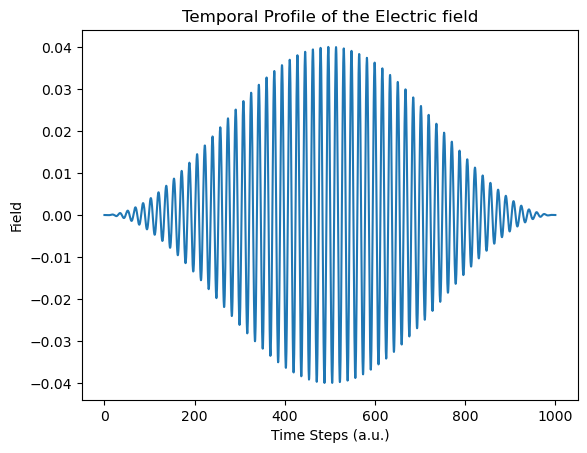

In [ ]:
psi0 = np.load("psi0.npy")
psi1 = np.load("psi1.npy")
psi2 = np.load("psi2.npy")
psi3 = np.load("psi3.npy")
a = np.load("a.npy")

# grid details
Delta_r = 0.2
N = 500
x_vec = np.linspace(-50, 50, N) 

V_softcore_vec = -1/np.sqrt(x_vec**2 + a**2)

# Real time step (Δt) and time grid
delta_t = 0.4
T = 1000 # in a.u.
t_vec = np.arange(0, T + delta_t, delta_t)

# External field 
E0 = 4e-2
omega01 = (-0.2329 - -0.4999) # difference b/w GS and First State
detuning = 0.05
omega = omega01 + detuning
E_t_vec = E0 * np.cos(np.pi * (t_vec - T/2) / T)**2 * np.cos(omega * t_vec)

# np.cos(np.pi * (t_vec - T/2) / T)**2 * np.cos(omega * t_vec)
plt.title("Temporal Profile of the Electric field")
plt.plot(t_vec[0:t_vec.size//1], E_t_vec[0:t_vec.size//1])
plt.xlabel("Time Steps (a.u.)")
plt.ylabel("Field")

In [32]:

# CALCULATIONS
psi = psi0.copy()
populations0 = np.zeros_like(t_vec)
populations1 = np.zeros_like(t_vec)
populations2 = np.zeros_like(t_vec)
populations3 = np.zeros_like(t_vec)

dipole_moment = np.zeros_like(t_vec)
dipole_moment01 = np.zeros_like(t_vec)
dipole_moment10 = np.zeros_like(t_vec)

for iter in range(t_vec.size):
    E_t = E_t_vec[iter] # choosing the field value corresponding to the current time step

    # modify V_l = V_softcore + E(t).x, for the CN matrices
    A_pl, A_mi, H_2, M_2 = create_Apl_Ami_Heff_M2_matrices(x_vec, V_softcore_vec + E_t * x_vec, Z=1, ell=0, deltaTau=delta_t)
        
    #CN propagation step
    A_pl_lower = get_lower(A_pl)
    A_pl_diag = get_diag(A_pl)
    A_pl_upper = get_upper(A_pl)

    psi_new = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi)
    psi = normalize(psi_new, x_vec)
        
    populations0[iter] = project(psi0, psi, x_vec) * np.conj(project(psi0, psi, x_vec))
    populations1[iter] = project(psi1, psi, x_vec) * np.conj(project(psi1, psi, x_vec))
    populations2[iter] = project(psi2, psi, x_vec) * np.conj(project(psi2, psi, x_vec))
    populations3[iter] = project(psi3, psi, x_vec) * np.conj(project(psi3, psi, x_vec))
    
    dipole_moment[iter] = project(psi, x_vec*psi, x_vec)
    dipole_moment01[iter] = project(psi0, x_vec * psi1, x_vec)
    dipole_moment10[iter] = project(psi1, x_vec * psi0, x_vec)

/tmp/ipykernel_115346/1383830429.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  populations0[iter] = project(psi0, psi, x_vec) * np.conj(project(psi0, psi, x_vec))
/tmp/ipykernel_115346/1383830429.py:27: ComplexWarning: Casting complex values to real discards the imaginary part
  populations1[iter] = project(psi1, psi, x_vec) * np.conj(project(psi1, psi, x_vec))
/tmp/ipykernel_115346/1383830429.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  populations2[iter] = project(psi2, psi, x_vec) * np.conj(project(psi2, psi, x_vec))
/tmp/ipykernel_115346/1383830429.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  populations3[iter] = project(psi3, psi, x_vec) * np.conj(project(psi3, psi, x_vec))
/tmp/ipykernel_115346/1383830429.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  dipole_moment[iter] = project(psi, x_vec*psi, x_vec)
/tmp/ipykernel_115346/1383

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_115346/778969189.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t_vec, populations0, label = "$|\psi_0|^2$")
/tmp/ipykernel_115346/778969189.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t_vec, populations1, label = "$|\psi_1|^2$")
/tmp/ipykernel_115346/778969189.py:5: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t_vec, populations2, label = "$|\psi_2|^2$")
/tmp/ipykernel_115346/778969189.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t_vec, populations3, label = "$|\psi_3|^2$")


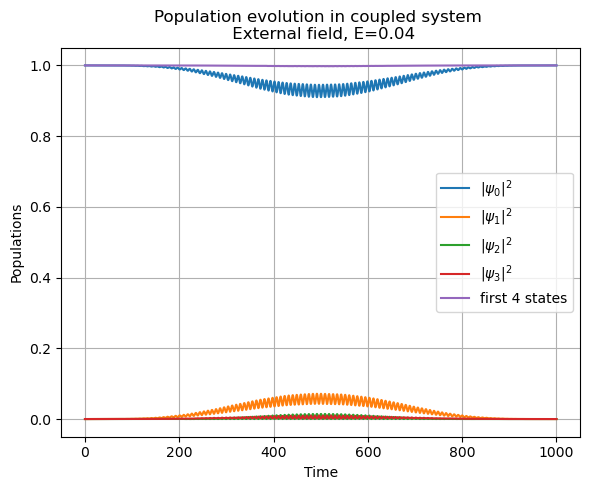

In [33]:
plt.subplots(figsize=(6, 5))

plt.plot(t_vec, populations0, label = "$|\psi_0|^2$")
plt.plot(t_vec, populations1, label = "$|\psi_1|^2$")
plt.plot(t_vec, populations2, label = "$|\psi_2|^2$")
plt.plot(t_vec, populations3, label = "$|\psi_3|^2$")
plt.plot(t_vec, populations0 + populations1 + populations2 + populations3, label = "first 4 states")




plt.legend()
plt.title(f"Population evolution in coupled system \n External field, E={E0}")
plt.ylabel("Populations")
plt.xlabel("Time")
plt.grid()
plt.tight_layout()


<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_115346/1582633360.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t_vec, populations0, label = "$|\psi_0|^2$")
/tmp/ipykernel_115346/1582633360.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t_vec, populations1, label = "$|\psi_1|^2$")
/tmp/ipykernel_115346/1582633360.py:10: SyntaxWarning: invalid escape sequence '\P'
  plt.title(f"Dipole Moment Evolution : $<\Psi(t)|x|\Psi(t)>$ \n Alongwith the populations of the first 2 states. \n Electric Field : {E0}")


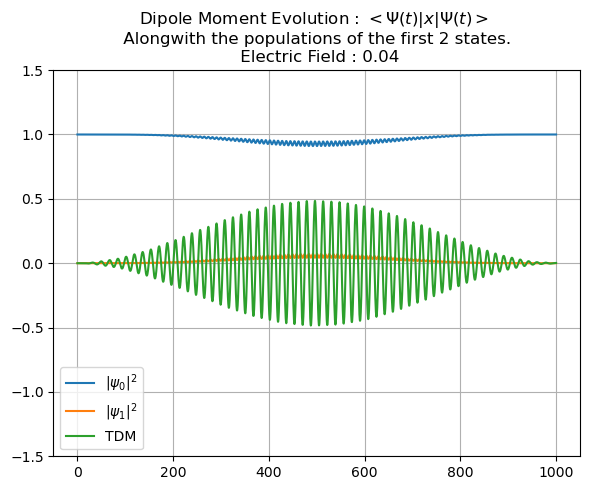

In [34]:
# dipole moment evolution plot
plt.subplots(figsize=(6, 5))
plt.plot(t_vec, populations0, label = "$|\psi_0|^2$")
plt.plot(t_vec, populations1, label = "$|\psi_1|^2$")
# plt.plot(t_vec, populations2, label = "$|\psi_2|^2$")
plt.plot(t_vec, dipole_moment, label = "TDM")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()
plt.title(f"Dipole Moment Evolution : $<\Psi(t)|x|\Psi(t)>$ \n Alongwith the populations of the first 2 states. \n Electric Field : {E0}")
plt.tight_layout()
plt.show()
plt.close()

Extraction of the Rabi Frequency at the peak (Extract peak E(t) and TDM first) to compare with the Theoretical value

WRONG !!!


Rabi Theoretical, Numerical (0.052000000000000005, 0.026668868027078036)


<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_115346/1548319176.py:13: SyntaxWarning: invalid escape sequence '\O'
  plt.title("Rabi Time periods for $\Omega_R$ - First State population")


235.60000000000002

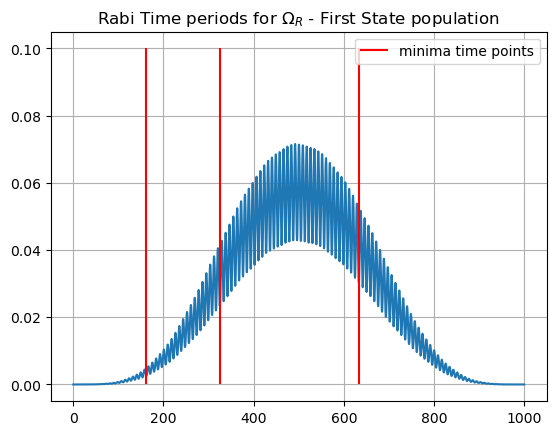

In [35]:
Rabi_frequency_theoretical = E0 * 1.3

"""IMPORTANT !! - The part below was run with t=0.5 steps"""
# Isolate the population plot for the n=0 state (As touches 0)
t1 = np.argmin(populations1[400:800]) + 400
t2 = np.argmin(populations1[800:1200]) + 800
t3 = np.argmin(populations1[1200:1600]) + 1200

plt.plot(t_vec, populations1)
plt.vlines(x = [t1 * delta_t, t2 * delta_t, t3* delta_t], ymin=0, ymax=0.1, color = "r", label= "minima time points")
plt.legend()
plt.grid()
plt.title("Rabi Time periods for $\Omega_R$ - First State population")


t12 = delta_t * (t2 - t1)
t23 = delta_t * (t3 - t2)

T_rabi = (t12 + t23)/2



Rabi_frequency_numerical = 2*np.pi / T_rabi
print("Rabi Theoretical, Numerical", (Rabi_frequency_theoretical, Rabi_frequency_numerical))
T_rabi


<>:11: SyntaxWarning: invalid escape sequence '\O'
<>:11: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_115346/471748815.py:11: SyntaxWarning: invalid escape sequence '\O'
  plt.title("Rabi Time periods for $\Omega_R$ - GS Population")


Rabi Theoretical, Numerical (0.052000000000000005, 0.10495298397293294)


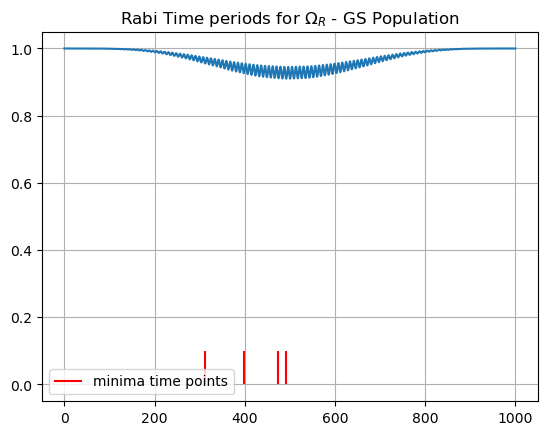

In [36]:
# Careful, rerun properly. VARIABLES FROM ABOVE reused and overwritten
t1 = np.argmin(populations0[400:800]) + 400
t2 = np.argmin(populations0[800:1000]) + 800
t3 = np.argmin(populations0[1000:1200]) + 1000
t4 =  np.argmin(populations0[1200: 1600]) + 1200

plt.plot(t_vec, populations0)
plt.vlines(x = [t1 * delta_t, t2 * delta_t, t3* delta_t, t4 * delta_t], ymin=0, ymax=0.1, color='r', label="minima time points")
plt.grid()
plt.legend()
plt.title("Rabi Time periods for $\Omega_R$ - GS Population")


t12 = delta_t * (t2 - t1)
t23 = delta_t * (t3 - t2)
t34 = delta_t * (t4 - t3)

T_rabi = (t12 + t23 + t34 )/3

Rabi_frequency_numerical = 2*np.pi / T_rabi
print("Rabi Theoretical, Numerical", (Rabi_frequency_theoretical, Rabi_frequency_numerical))
